<a href="https://colab.research.google.com/github/Kumar-642/Learning-based-Parkinson-s-Disease-Monitoring-System-through-Hardware-Software-Co-Simulation/blob/main/01_Python/Parkinson_CNN_Meander_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Important Libraries

> This section initializes the workspace by importing the core "toolkits" required for deep learning and image processing.

  >> **TensorFlow & Keras**: The primary framework used to build, train, and validate the neural network architecture.

  >> **OpenCV & NumPy**: These libraries handle the heavy lifting for image manipulation and the matrix mathematics required to process pixel data.

  >> **Matplotlib**: Used for data visualization to ensure that the spiral drawings are being loaded and preprocessed correctly.

In [1]:
import os
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Importing Data and Splitting

> This stage focuses on organizing the dataset to ensure the model learns effectively.
  >> **Image Loading**: The script reads raw spiral drawings from the directory and standardizes them to a $128 \times 128$ resolution.
  
  >> **Dataset Partitioning**: The data is split into Training (80%) to teach the model patterns and Validation (20%) to test the model's accuracy on unseen data.

In [3]:
import tensorflow as tf

# 1. Dataset Configuration (Keep your paths and split)
base_path = '/content/drive/MyDrive/Parksion_MTP/Meander_HandPD'

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=16,
    color_mode='grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=16,
    color_mode='grayscale'
)

Found 368 files belonging to 2 classes.
Using 295 files for training.
Found 368 files belonging to 2 classes.
Using 73 files for validation.


# Normalize Data

Raw image pixels typically range from $0$ to $255$. This section rescales them to a floating-point range of $[0, 1]$.
  >> **Efficiency**: Normalization ensures the mathematical gradients during training remain stable and converge faster.

  >> **Autotuning**: We use *tf.data.AUTOTUNE* to pre-fetch data into memory, preventing the processor from idling while waiting for disk I/O.

In [4]:
# This rescales pixels to [0,1] and optimizes memory loading
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Autotune improves training speed in Colab
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

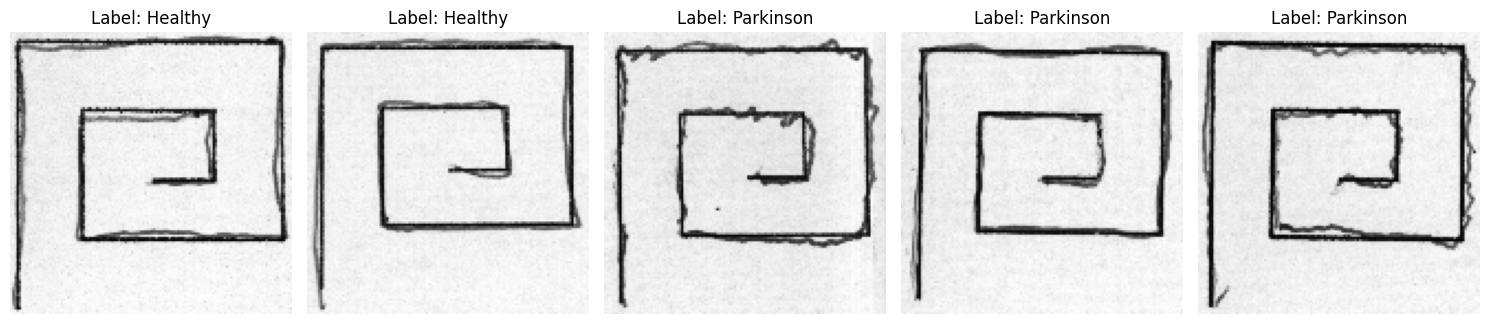

In [5]:
class_names = ['Healthy', 'Parkinson']

# Take one batch from the training set
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 5))
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        # Display the image (rescaled back to 0-255 for plotting if needed,
        # but matplotlib handles 0-1 float well)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(f"Label: {class_names[labels[i]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break

# Model

> We define a Convolutional Neural Network (CNN), which is specifically designed to recognize spatial patterns like tremors in handwriting.

  >> **Feature Extraction**: Convolutional layers identify key visual features (shaky lines), while Pooling layers reduce the data size to focus only on the most important information.

  >> **Classification**: The final "Dense" layer acts as the decision-maker, outputting the probability of the drawing belonging to the Healthy or Parkinson's class.

In [6]:
model = models.Sequential([
    # Input: (128, 128, 1)
    layers.InputLayer(input_shape=(128, 128, 1)),

    # Layer 1: Conv1 + Pool1
    # 128x128 -> 126x126 (Conv) -> 31x31 (Pool 4x4)
    layers.Conv2D(4, (3, 3), activation='relu', name='conv1'),
    layers.MaxPooling2D((4, 4), name='pool1'),

    # Layer 2: Conv2 + Pool2
    # 31x31 -> 29x29 (Conv) -> 7x7 (Pool 4x4)
    layers.Conv2D(8, (3, 3), activation='relu', name='conv2'),
    layers.MaxPooling2D((4, 4), name='pool2'),

    # Layer 3: Final Dense
    # Flattening 7x7x8 = 392 elements
    layers.Flatten(name='flatten'),

    # output logits
    layers.Dense(2, name='dense_out')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 126, 126, 4)    │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 31, 31, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 29, 29, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (Dense)               │ (None, 2)              │           786 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122 (4.38 KB)

 Trainable params: 1,122 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Training Model

In [9]:
# 1. Train the model and capture the history
print("Training on 564 images...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Training on 564 images...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 945ms/step - accuracy: 0.8068 - loss: 0.5213 - val_accuracy: 0.7671 - val_loss: 0.5714
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.8136 - loss: 0.4812 - val_accuracy: 0.7671 - val_loss: 0.5370
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8136 - loss: 0.4737 - val_accuracy: 0.7671 - val_loss: 0.5404
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8136 - loss: 0.4729 - val_accuracy: 0.7671 - val_loss: 0.5378
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8136 - loss: 0.4706 - val_accuracy: 0.7671 - val_loss: 0.5357
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8136 - loss: 0.4687 - val_accuracy: 0.7671 - val_loss: 0.5337
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8136 - loss: 0.4664 - val_accuracy: 0.7671 - val_loss: 0.5308
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8136 - loss: 0.4

In [10]:
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titleweight': 'bold'
})

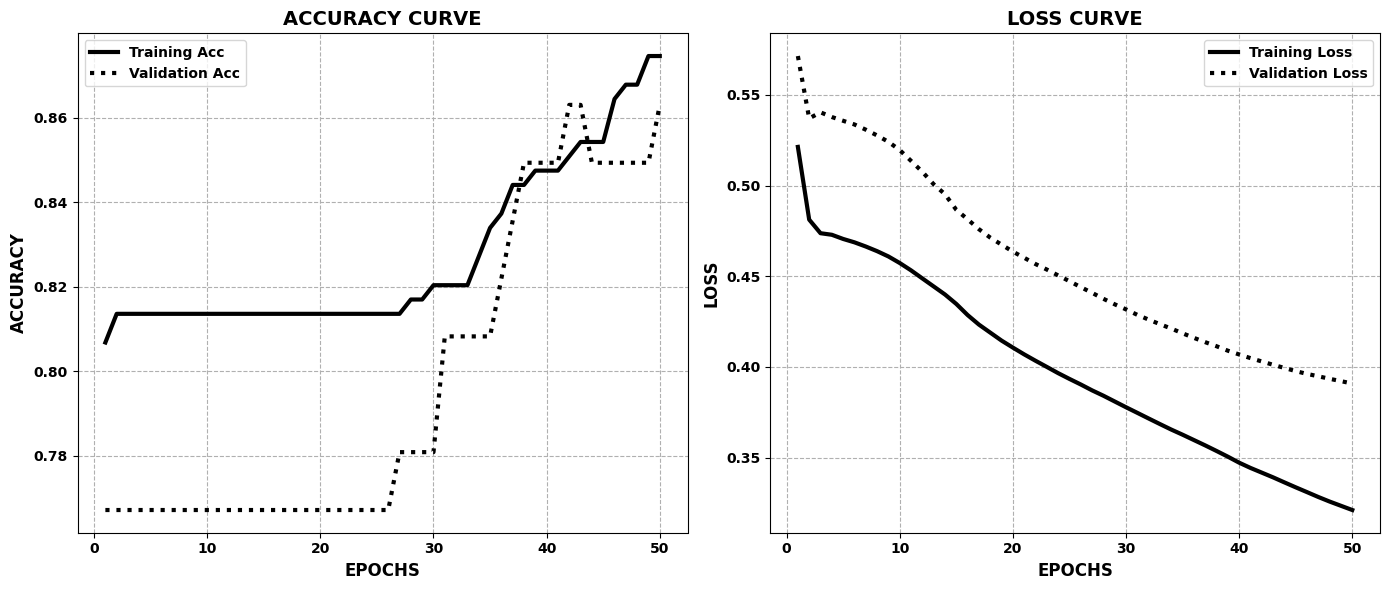

In [11]:
def plot_learning_curves_bold_clean(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, color='black', linestyle='-', linewidth=3, label='Training Acc')
    plt.plot(epochs, val_acc, color='black', linestyle=':', linewidth=3, label='Validation Acc')
    plt.title('ACCURACY CURVE', fontsize=14)
    plt.xlabel('EPOCHS', fontsize=12)
    plt.ylabel('ACCURACY', fontsize=12)
    plt.legend(prop={'weight':'bold'})
    plt.grid(True, linestyle='--')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, color='black', linestyle='-', linewidth=3, label='Training Loss')
    plt.plot(epochs, val_loss, color='black', linestyle=':', linewidth=3, label='Validation Loss')
    plt.title('LOSS CURVE', fontsize=14)
    plt.xlabel('EPOCHS', fontsize=12)
    plt.ylabel('LOSS', fontsize=12)
    plt.legend(prop={'weight':'bold'})
    plt.grid(True, linestyle='--')

    plt.tight_layout()
    plt.show()

plot_learning_curves_bold_clean(history)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

        FINAL STATISTICAL RESULTS
PRECISION:    0.8594
SENSITIVITY:  0.9821
SPECIFICITY:  0.4706
F1-SCORE:     0.9167


<Figure size 600x500 with 0 Axes>

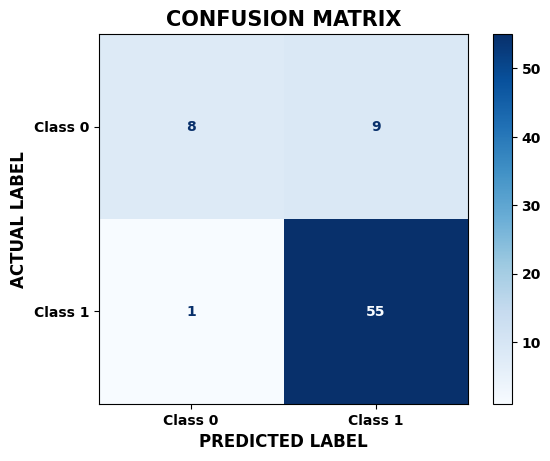

In [12]:
# 1. Predictions
y_true = np.concatenate([y for x, y in val_ds], axis=0)
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)

# 2. Confusion Matrix Components
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 3. Calculate Bold Metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0      # Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "="*40)
print("        FINAL STATISTICAL RESULTS")
print("="*40)
print(f"PRECISION:    {precision:.4f}")
print(f"SENSITIVITY:  {recall:.4f}")
print(f"SPECIFICITY:  {specificity:.4f}")
print(f"F1-SCORE:     {f1_score:.4f}")
print("="*40)

# 4. Bold Heatmap
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title('CONFUSION MATRIX', fontweight='bold', fontsize=15)
plt.ylabel('ACTUAL LABEL', fontweight='bold', fontsize=12)
plt.xlabel('PREDICTED LABEL', fontweight='bold', fontsize=12)
plt.show()

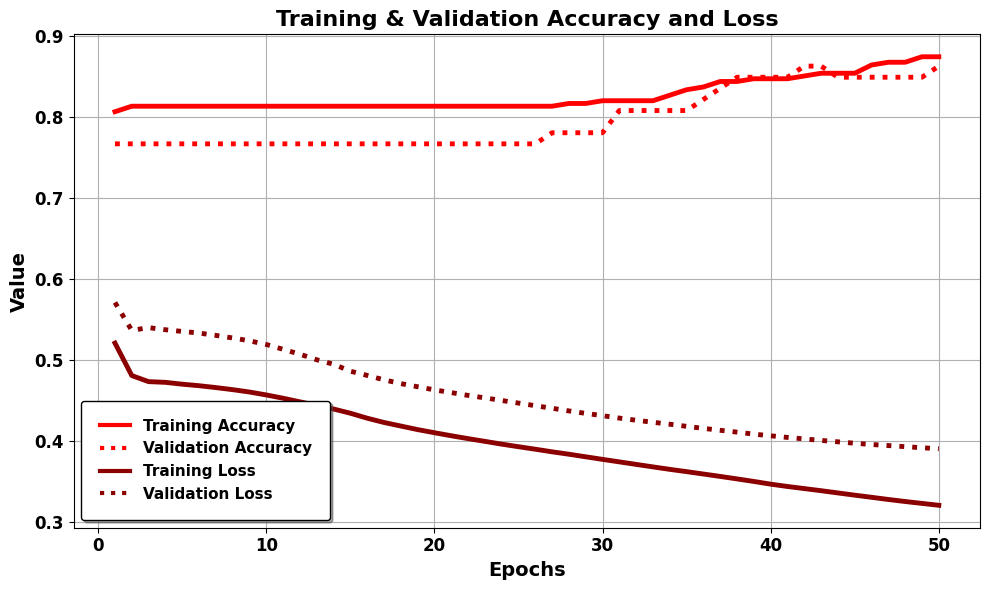

In [13]:
epochs = range(1, len(history.history['accuracy']) + 1)

train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss   = history.history['val_loss']

plt.figure(figsize=(10, 6))

# ---- Accuracy curves ----
plt.plot(epochs, train_acc, color='red', linewidth=3.5, label='Training Accuracy')
plt.plot(epochs, val_acc, color='red', linestyle='dotted', linewidth=3.5, label='Validation Accuracy')

# ---- Loss curves ----
plt.plot(epochs, train_loss, color='#8B0000', linewidth=3.5, label='Training Loss')
plt.plot(epochs, val_loss, color='#8B0000', linestyle='dotted', linewidth=3.5, label='Validation Loss')

# ---- Labels with larger font ----
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Value', fontsize=14, fontweight='bold')
plt.title('Training & Validation Accuracy and Loss', fontsize=16, fontweight='bold')

# ---- Increase tick (digit) size ----
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# ---- Create and style legend ----
legend = plt.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1,
    shadow=True,
    borderpad=1.2
)

# Make legend text bold
for text in legend.get_texts():
    text.set_fontweight('bold')

# Make legend lines thicker (so they match plot prominence)
for line in legend.get_lines():
    line.set_linewidth(3)

plt.grid(True)
plt.tight_layout()
plt.show()


# Import Files

> Since an FPGA cannot execute Python code directly, this section bridges the gap between the ML model and the ZedBoard hardware.

  >> **Weight Extraction**: We export the "learned knowledge" (weights and biases) into a C++ header file (weights.h).

  >> **HLS Compatibility**: The data is formatted for High-Level Synthesis (HLS), allowing the model to run as a high-speed hardware accelerator on the Zynq SoC.

  >> **Golden Verification**: We export test binaries (input_img.bin and golden_logits.bin) to ensure the hardware's output perfectly matches the Python model's predictions.

In [14]:
import numpy as np
from google.colab import files

def download_hls_package(model, dataset):
    # --- 1. GENERATE weights.h ---
    with open('weights.h', 'w') as f:
        f.write("#ifndef WEIGHTS_H\n#define WEIGHTS_H\n\n")

        for layer in model.layers:
            if len(layer.get_weights()) > 0:
                w, b = layer.get_weights()
                base_name = layer.name.replace('dense_out', 'dense')

                # Transpose for C++ Row-Major logic
                if 'conv' in layer.name:
                    w = np.transpose(w, (3, 2, 0, 1)) # [Out, In, H, W]
                else:
                    w = w.T # [Out, In]

                # Write Weights
                w_flat = w.flatten()
                f.write(f"const float {base_name}_w_init[{len(w_flat)}] = {{\n")
                f.write(", ".join([f"{x:.8f}f" for x in w_flat]))
                f.write("\n};\n\n")

                # Write Biases
                b_flat = b.flatten()
                f.write(f"const float {base_name}_b_init[{len(b_flat)}] = {{\n")
                f.write(", ".join([f"{x:.8f}f" for x in b_flat]))
                f.write("\n};\n\n")

        f.write("#endif // WEIGHTS_H")

    # --- 2. GENERATE TEST BINARIES ---
    for images, labels in dataset.take(1):
        test_img = images[0:1].numpy()
        break

    test_img.astype(np.float32).tofile('input_img.bin')
    golden_logits = model.predict(test_img)
    golden_logits.astype(np.float32).tofile('golden_logits.bin')

    # --- 3. TRIGGER DOWNLOADS ---
    print("Downloading files...")
    files.download('weights.h')
    files.download('input_img.bin')
    files.download('golden_logits.bin')

# Call the function
download_hls_package(model, val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>